In [1]:
from Bio import Entrez, Blast, SeqIO
import re
import json

In [2]:
Entrez.email = "blucardi@gmail.com"

In [3]:
blast_results_filename = "blast_results/TGY601W6014-Alignment(tblastn from web).xml"

# with open(blast_results_filename) as f:
#     blast_results_string = f.read()

blast_records = Blast.parse(blast_results_filename)
blast_records_list = list(blast_records)

In [4]:
print(blast_records)

Program: TBLASTN 2.17.0+
     db: core_nt

  Query: Query_8100162 (length=1258)
         AAA24823.1 ice nucleation protein [Pantoea agglomerans]
   Hits: No hits found

  Query: Query_8100163 (length=195)
         AAA49617.1 antifreeze polypeptide (AFP) precursor [Hemitripterus
         americanus]
   Hits: ----  -----  ----------------------------------------------------------
            #  # HSP  ID + description
         ----  -----  ----------------------------------------------------------
            0      1  gi|2700941652|ref|XM_063837581.1|  PREDICTED: Bolinopsi...
            1      1  gi|2700972406|ref|XM_063826959.1|  PREDICTED: Bolinopsi...
            2      2  gi|2700955919|ref|XM_063818157.1|  PREDICTED: Bolinopsi...
            3      1  gi|2700956383|ref|XM_063818403.1|  PREDICTED: Bolinopsi...
            4      1  gi|2700972404|ref|XM_063826957.1|  PREDICTED: Bolinopsi...
            5      1  gi|2700972402|ref|XM_063826956.1|  PREDICTED: Bolinopsi...
            6

In [5]:
# print(blast_records[2][1])

In [6]:
reference_id = blast_records_list[2][1].target.id
reference_id

'gi|2700972406|ref|XM_063826959.1|'

In [7]:
reference_ids = []
for query in blast_records_list:
    for hit in query:
        reference_ids.append(hit.target.id)
# reference_ids

In [125]:
def sanitize_reference_id(reference_id):
    # Extract the part after the last '|'
    return reference_id.split("|")[-2]

In [126]:
search_string = ",".join([sanitize_reference_id(s) for s in set(reference_ids)])
search_string

'XM_063837207.1,XM_063832265.1,XM_063826956.1,XM_063817999.1,XM_063826957.1,XM_063833069.1,XM_063818157.1,XM_063833072.1,XM_063833648.1,XM_063824909.1,XM_063832689.1,XM_063825900.1,XM_063833404.1,XM_063837581.1,XM_063822536.1,XM_063838129.1,XM_063818403.1,XM_063833071.1,XM_063826959.1,XM_063836312.1,XM_063822534.1,XM_063832653.1,XM_063835162.1,XM_063833070.1,XM_063822663.1'

In [30]:
stream = Entrez.efetch(db="nucleotide", id=search_string, rettype="fasta_cds_na", retmode="text")
cdss = list(SeqIO.parse(stream, "fasta"))
stream.close()

# list(cdss)

locations = {re.search(r"\[gene=([^\]]+)\]", s.description).group(1) : { "accessionID" : re.search(r"\|([^_]+_[^_]+)_", s.id).group(1)} for s in cdss }

search_string = ",".join(list(locations.keys()))


In [31]:
locations

{'LOC134825079': {'accessionID': 'XM_063837207.1'},
 'LOC134821560': {'accessionID': 'XM_063832265.1'},
 'LOC134817716': {'accessionID': 'XM_063826957.1'},
 'LOC134811229': {'accessionID': 'XM_063817999.1'},
 'LOC134822162': {'accessionID': 'XM_063833070.1'},
 'LOC134811364': {'accessionID': 'XM_063818157.1'},
 'LOC134822539': {'accessionID': 'XM_063833648.1'},
 'LOC134816142': {'accessionID': 'XM_063824909.1'},
 'LOC134821881': {'accessionID': 'XM_063832689.1'},
 'LOC134816896': {'accessionID': 'XM_063825900.1'},
 'LOC134822376': {'accessionID': 'XM_063833404.1'},
 'LOC134825402': {'accessionID': 'XM_063837581.1'},
 'LOC134814426': {'accessionID': 'XM_063822536.1'},
 'LOC134825929': {'accessionID': 'XM_063838129.1'},
 'LOC134811532': {'accessionID': 'XM_063818403.1'},
 'LOC134817717': {'accessionID': 'XM_063826959.1'},
 'LOC134824410': {'accessionID': 'XM_063836312.1'},
 'LOC134814423': {'accessionID': 'XM_063822534.1'},
 'LOC134821842': {'accessionID': 'XM_063832653.1'},
 'LOC1348236

In [32]:

search_string

'LOC134825079,LOC134821560,LOC134817716,LOC134811229,LOC134822162,LOC134811364,LOC134822539,LOC134816142,LOC134821881,LOC134816896,LOC134822376,LOC134825402,LOC134814426,LOC134825929,LOC134811532,LOC134817717,LOC134824410,LOC134814423,LOC134821842,LOC134823628,LOC134814511'

In [33]:
stream = Entrez.efetch(db="gene", id=search_string, rettype="full", retmode="text")
# records = SeqIO.parse(stream, "text")
# accessions = {sequence.id: sequence for sequence in records}
# stream.close()
# record = Entrez.read(stream)
# print(accessions)
data = stream.read()
print(data)
# print(record)


1. LOC134825079
uncharacterized LOC134825079 [Bolinopsis microptera]
Other Designations: uncharacterized protein LOC134825079
Chromosome: 13
Annotation: Chromosome 13 NC_087084.1 (344144..377661)
ID: 134825079

2. LOC134821560
keratin-associated protein 16-1-like [Bolinopsis microptera]
Other Designations: keratin-associated protein 16-1-like
Chromosome: 10
Annotation: Chromosome 10 NC_087081.1 (7490523..7492973)
ID: 134821560

3. LOC134817716
uncharacterized LOC134817716 [Bolinopsis microptera]
Other Designations: uncharacterized protein LOC134817716
Chromosome: 7
Annotation: Chromosome 7 NC_087078.1 (4343407..4412247)
ID: 134817716

4. LOC134811229
uncharacterized LOC134811229 [Bolinopsis microptera]
Other Designations: uncharacterized protein LOC134811229
Chromosome: 1
Annotation: Chromosome 1 NC_087072.1 (9537820..9539178)
ID: 134811229

5. LOC134822162
contactin-6-like [Bolinopsis microptera]
Other Designations: contactin-6-like
Chromosome: 10
Annotation: Chromosome 10 NC_087081.

In [34]:
pattern = re.compile(
    r"(LOC\d+).*?\[(.+?)\].*?Chromosome:\s*(\d+).*?Annotation:\s*Chromosome\s*\d+\s+(NC_\d+\.\d+)\s*\((\d+)\.\.(\d+)",
    re.S
)

matches = pattern.findall(data)


for loc, species_name, chrom, accession, start, end in matches:
    print(loc, species_name, chrom, accession, start, end)

    locations[loc] |= {
        "chrom": chrom,
        "species_name": species_name,
        "start": start,
        "end": end,
        "accession": accession,
    }

locations

LOC134825079 Bolinopsis microptera 13 NC_087084.1 344144 377661
LOC134821560 Bolinopsis microptera 10 NC_087081.1 7490523 7492973
LOC134817716 Bolinopsis microptera 7 NC_087078.1 4343407 4412247
LOC134811229 Bolinopsis microptera 1 NC_087072.1 9537820 9539178
LOC134822162 Bolinopsis microptera 10 NC_087081.1 3074461 3086221
LOC134811364 Bolinopsis microptera 2 NC_087073.1 17463856 17492435
LOC134822539 Bolinopsis microptera 11 NC_087082.1 10873466 10886829
LOC134816142 Bolinopsis microptera 5 NC_087076.1 4293936 4312124
LOC134821881 Bolinopsis microptera 10 NC_087081.1 5342760 5364571
LOC134816896 Bolinopsis microptera 6 NC_087077.1 9742091 9752017
LOC134822376 Bolinopsis microptera 10 NC_087081.1 32969 38478
LOC134825402 Bolinopsis microptera 1 NC_087072.1 491081 554815
LOC134814426 Bolinopsis microptera 4 NC_087075.1 4098515 4119964
LOC134825929 Bolinopsis microptera 1 NC_087072.1 2007048 2010642
LOC134811532 Bolinopsis microptera 2 NC_087073.1 7505332 7507937
LOC134817717 Bolinopsis

{'LOC134825079': {'accessionID': 'XM_063837207.1',
  'chrom': '13',
  'species_name': 'Bolinopsis microptera',
  'start': '344144',
  'end': '377661',
  'accession': 'NC_087084.1'},
 'LOC134821560': {'accessionID': 'XM_063832265.1',
  'chrom': '10',
  'species_name': 'Bolinopsis microptera',
  'start': '7490523',
  'end': '7492973',
  'accession': 'NC_087081.1'},
 'LOC134817716': {'accessionID': 'XM_063826957.1',
  'chrom': '7',
  'species_name': 'Bolinopsis microptera',
  'start': '4343407',
  'end': '4412247',
  'accession': 'NC_087078.1'},
 'LOC134811229': {'accessionID': 'XM_063817999.1',
  'chrom': '1',
  'species_name': 'Bolinopsis microptera',
  'start': '9537820',
  'end': '9539178',
  'accession': 'NC_087072.1'},
 'LOC134822162': {'accessionID': 'XM_063833070.1',
  'chrom': '10',
  'species_name': 'Bolinopsis microptera',
  'start': '3074461',
  'end': '3086221',
  'accession': 'NC_087081.1'},
 'LOC134811364': {'accessionID': 'XM_063818157.1',
  'chrom': '2',
  'species_name':

In [35]:
import pandas as pd

In [36]:
df = pd.DataFrame(locations)

In [60]:
df = df.transpose()
df

,accessionID,chrom,species_name,start,end,accession
LOC134825079,XM_063837207.1,13,Bolinopsis microptera,344144,377661,NC_087084.1
LOC134821560,XM_063832265.1,10,Bolinopsis microptera,7490523,7492973,NC_087081.1
LOC134817716,XM_063826957.1,7,Bolinopsis microptera,4343407,4412247,NC_087078.1
LOC134811229,XM_063817999.1,1,Bolinopsis microptera,9537820,9539178,NC_087072.1
LOC134822162,XM_063833070.1,10,Bolinopsis microptera,3074461,3086221,NC_087081.1
LOC134811364,XM_063818157.1,2,Bolinopsis microptera,17463856,17492435,NC_087073.1
LOC134822539,XM_063833648.1,11,Bolinopsis microptera,10873466,10886829,NC_087082.1
LOC134816142,XM_063824909.1,5,Bolinopsis microptera,4293936,4312124,NC_087076.1
LOC134821881,XM_063832689.1,10,Bolinopsis microptera,5342760,5364571,NC_087081.1
LOC134816896,XM_063825900.1,6,Bolinopsis microptera,9742091,9752017,NC_087077.1


In [63]:
unique_species_names = set(df["species_name"])
unique_species_names

{'Bolinopsis microptera'}

In [84]:
species = {name: dict() for name in unique_species_names}

for name in unique_species_names:
    stream = Entrez.esearch(db="taxonomy", term=name, retmode="xml")
    results = Entrez.read(stream)
    print(results)

    # Just take the first id for the animal
    species[name] |= { "species_id" : results["IdList"][0]}

    # stream = Entrez.efetch(db="genome", id=species[name]["id"], retmode="xml")
    # results = Entrez.read(stream)
    # print(results)

    # handle = Entrez.elink(dbfrom="taxonomy", db="assembly", id=species[name]["id"], linkname="taxonomy_assembly")
    # record = Entrez.read(handle)

    handle = Entrez.esearch(db="assembly", term=f"txid{species[name]['species_id'] }[Organism]", retmax="1")
    record = Entrez.read(handle)
    print(record)

    assembly_ids = record["IdList"]

    handle = Entrez.esummary(db="assembly", id=",".join(assembly_ids), report="full")
    summary_records = Entrez.read(handle)
    genome_accession_id = summary_records["DocumentSummarySet"]["DocumentSummary"][0]['AssemblyAccession']
    # print()

    species[name] |= { "genome_accession_id" : genome_accession_id}
    handle.close()


species

{'Count': '1', 'RetMax': '1', 'RetStart': '0', 'IdList': ['2820187'], 'TranslationSet': [], 'TranslationStack': [{'Term': 'Bolinopsis microptera[All Names]', 'Field': 'All Names', 'Count': '1', 'Explode': 'N'}, 'GROUP'], 'QueryTranslation': 'Bolinopsis microptera[All Names]'}
{'Count': '1', 'RetMax': '1', 'RetStart': '0', 'IdList': ['14401481'], 'TranslationSet': [], 'TranslationStack': [{'Term': 'txid2820187[Organism]', 'Field': 'Organism', 'Count': '1', 'Explode': 'Y'}, 'GROUP'], 'QueryTranslation': 'txid2820187[Organism]'}


{'Bolinopsis microptera': {'species_id': '2820187',
  'genome_accession_id': 'GCF_026151205.1'}}

In [113]:
import urllib.request
chroms = {}
for key, specie in species.items():

    # search_handle = Entrez.esearch(db="nuccore", term=f"{specie['genome_accession_id']}[Assembly]", retmax=100)
    # search_results = Entrez.read(search_handle)
    # search_handle.close()
    #
    # id_list = search_results["IdList"]
    #
    # # Fetching as 'gb' (GenBank) allows parsing of names/lengths
    # fetch_handle = Entrez.efetch(db="nuccore", id=id_list, rettype="gb", retmode="text")

    # print(fetch_handle.read())


    search = Entrez.esearch(
        db="assembly",
        term=specie["genome_accession_id"],
        retmode="xml"
    )

    search_record = Entrez.read(search)
    uid = search_record["IdList"][0]

    print("UID:", uid)

    summary = Entrez.esummary(
        db="assembly",
        id=uid,
        retmode="xml"
    )

    record = Entrez.read(summary)
    print(record)

    # Generated, be careful
    # todo: reread for correctness.

    doc = record["DocumentSummarySet"]["DocumentSummary"][0]
    assembly_rpt_url = doc["FtpPath_Assembly_rpt"]

    # Download assembly report
    with urllib.request.urlopen(assembly_rpt_url) as response:
        lines = response.read().decode("utf-8").splitlines()

    chrom_sizes = {}

    for line in lines:
        if line.startswith("#"):
            continue
        fields = line.split("\t")

        sequence_role = fields[1]
        sequence_name = fields[2]
        sequence_length = int(fields[8])

        if sequence_role == "assembled-molecule":
            chrom_sizes[sequence_name] = sequence_length

    print(chrom_sizes)
    # for record in SeqIO.parse(handle, "fasta"):
    #     print(record.id, len(record.seq))
    #     handle.close()

    chroms[key] = chrom_sizes





UID: 14401481
{'DocumentSummarySet': DictElement({'DocumentSummary': [DictElement({'RsUid': '54911008', 'GbUid': '37374548', 'AssemblyAccession': 'GCF_026151205.1', 'LastMajorReleaseAccession': 'GCF_026151205.1', 'LatestAccession': '', 'ChainId': '26151205', 'AssemblyName': 'MBARI_Bmic_1.0', 'UCSCName': '', 'EnsemblName': '', 'Taxid': '2820187', 'Organism': 'Bolinopsis microptera (comb jellies)', 'SpeciesTaxid': '2820187', 'SpeciesName': 'Bolinopsis microptera', 'AssemblyType': 'haploid', 'AssemblyStatus': 'Chromosome', 'AssemblyStatusSort': '3', 'WGS': 'JAIOUN01', 'GB_BioProjects': [{'BioprojectAccn': 'PRJNA759908', 'BioprojectId': '759908'}], 'GB_Projects': [], 'RS_BioProjects': [{'BioprojectAccn': 'PRJNA1087296', 'BioprojectId': '1087296'}], 'RS_Projects': [], 'BioSampleAccn': 'SAMN21208954', 'BioSampleId': '21208954', 'Biosource': {'InfraspeciesList': [{'Sub_type': 'specimen-voucher', 'Sub_value': 'NA, consumed'}], 'Sex': 'hermaphrodite', 'Isolate': 'Bmic1'}, 'Coverage': '108', 'Pa

In [ ]:
# df[df['column_name'] == some_value]

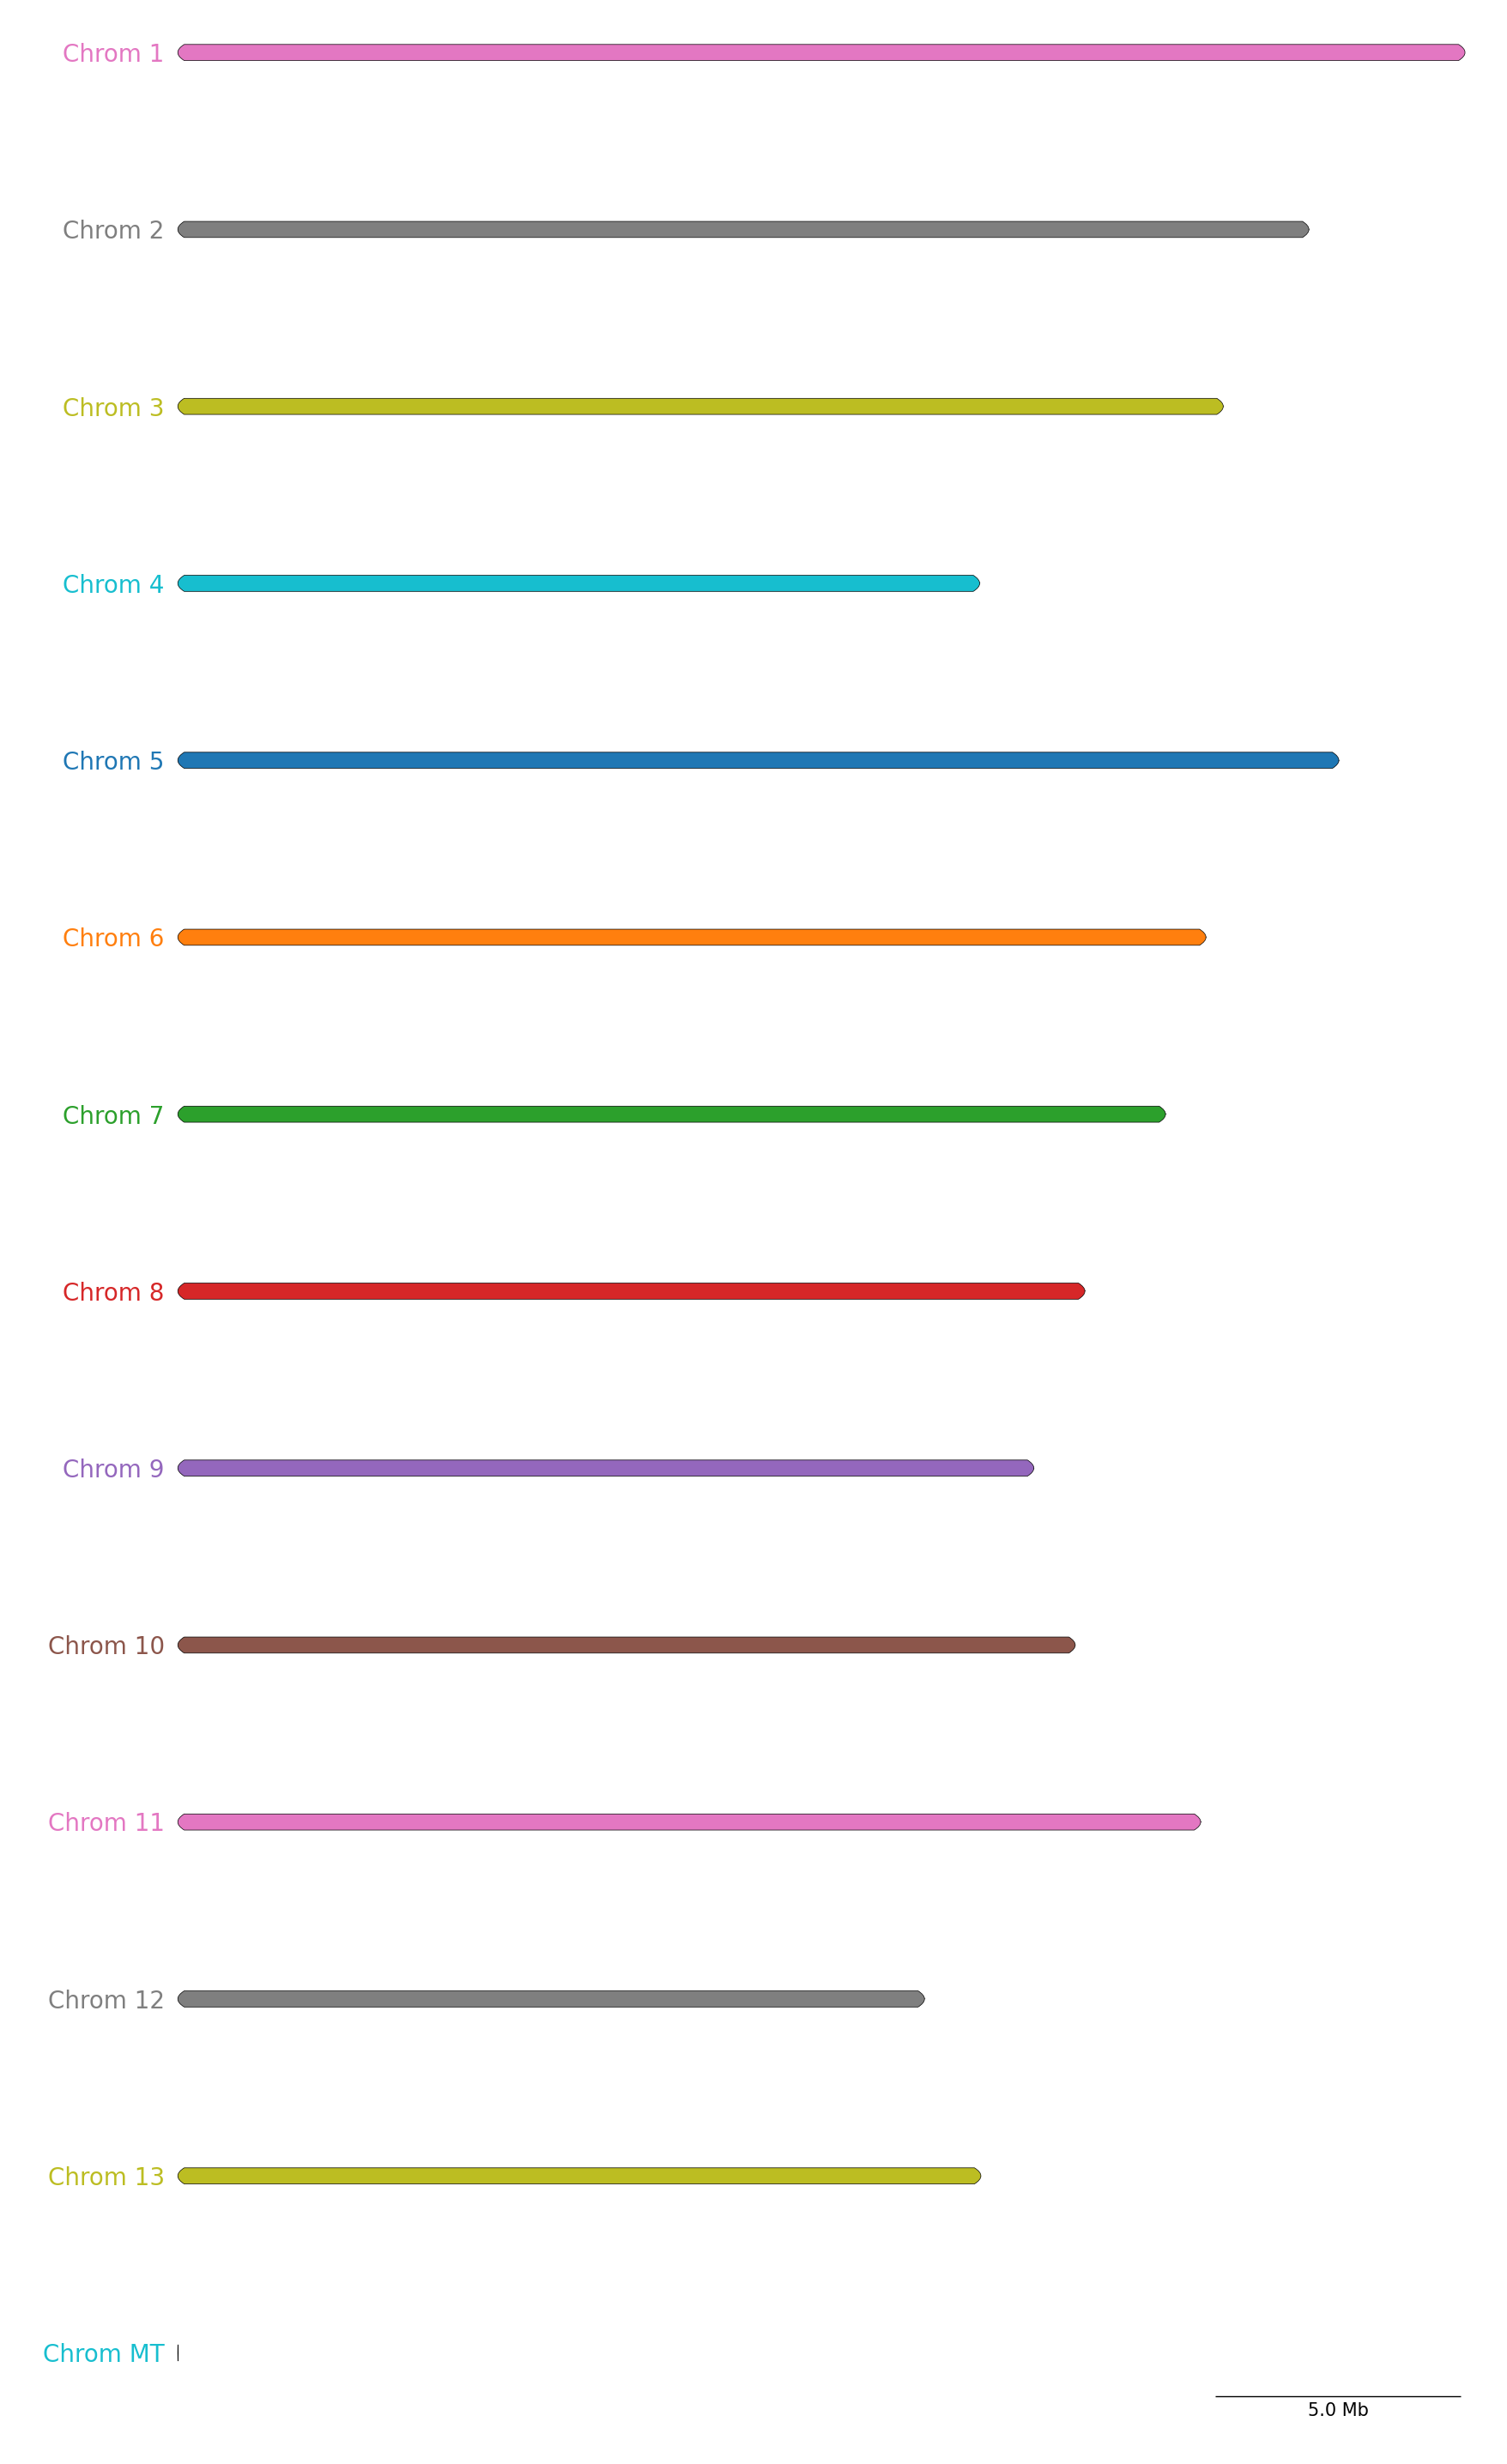

In [146]:
from pygenomeviz import GenomeViz
from pygenomeviz.align import MUMmer
from pygenomeviz.parser import Genbank
from pygenomeviz.utils import load_example_genbank_dataset, ColorCycler
# ColorCycler.set_cmap("tab10")

# gbk_files = load_example_genbank_dataset("saccharomyces")
# gbk_list = list(map(Genbank, gbk_files))

gv = GenomeViz(feature_track_ratio=0.1)
gv.set_scale_bar(ymargin=2.0)

# Plot chromosomes
# for gbk in gbk_list:
for chrom, chrom_size in chroms["Bolinopsis microptera"].items():
    color = ColorCycler()
    track = gv.add_feature_track(f"Chrom {chrom}", chrom_size, space=0.01, label_kws=dict(color=color))
    track.set_label(track.name.replace("_", "\n"))
    for segment in track.segments:
        segment.add_feature(segment.start, segment.end, plotstyle="bigrbox", fc=color, lw=0.5)

# Run MUMmer alignment
# align_coords = MUMmer(gbk_list).run()

# Plot MUMmer alignment links
# if len(align_coords) > 0:
#     for ac in align_coords:
#         gv.add_link(ac.query_link, ac.ref_link, color="grey", inverted_color="red", curve=True, filter_length=1000)
#
# for hit in blast_records_list[2]:
#     id = hit.target.id
#
#     data = df[df["accessionID"] == id][0]
#
#     query_link = (f"Chrom {data['chrom']}", int(data["start"]), int(data["end"]))
#     ref_link = (f"Chrom {data['chrom']}", int(hit.target.start), int(hit.target.end))
#
#     gv.add_link(query_link, ref_link, color="grey", inverted_color="red", curve=True, filter_length=1000)

# for ac in align_coords:
#     gv.add_link(ac.query_link, ac.ref_link, color="grey", inverted_color="red", curve=True, filter_length=1000)

# for hit in blast_records_list[2]:
#     id = sanitize_reference_id(hit.target.id)
#     data = df[df["accessionID"] == id]
#
#     if data.empty:
#             continue
#
#     query_link = (f"Chrom {str(data['chrom'].iloc[0])}", int(data["start"].iloc[0]), int(data["end"].iloc[0]))
#
#
#     for hit2 in blast_records_list[2]:
#         id2 = sanitize_reference_id(hit2.target.id)
#         data2 = df[df["accessionID"] == id2]
#         if data2.empty:
#             continue
#
#         # if str(data['chrom'].iloc[0]) == f"Chrom {str(data2['chrom'].iloc[0])}":
#         #     continue
#
#         # print(data2)
#         ref_link = (f"Chrom {str(data2['chrom'].iloc[0])}", int(data2["start"].iloc[0]), int(data2["end"].iloc[0]))
#
#         if query_link[0] == ref_link[0]:
#             continue
#
#         gv.add_link(query_link, ref_link, color="grey", inverted_color="red", curve=True, filter_length=1000)


fig = gv.plotfig()

In [139]:
for hit in blast_records_list[2]:
    id = sanitize_reference_id(hit.target.id)
    data = df[df["accessionID"] == id]

    if data.empty:
            continue

    query_link = (f"Chrom {str(data['chrom'].iloc[0])}", int(data["start"].iloc[0]), int(data["end"].iloc[0]))


    for hit2 in blast_records_list[2]:
        id2 = sanitize_reference_id(hit2.target.id)
        data2 = df[df["accessionID"] == id2]
        if data2.empty:
            continue

        # print(data2)
        ref_link = (f"Chrom {str(data2['chrom'].iloc[0])}", int(data2["start"].iloc[0]), int(data2["end"].iloc[0]))

        # print(query_link, ref_link)

                 accessionID chrom           species_name   start     end  \
LOC134825402  XM_063837581.1     1  Bolinopsis microptera  491081  554815   

                accession  
LOC134825402  NC_087072.1  
('Chrom 1', 491081, 554815) ('Chrom 1', 491081, 554815)
                 accessionID chrom           species_name    start      end  \
LOC134817717  XM_063826959.1     7  Bolinopsis microptera  4412928  4417617   

                accession  
LOC134817717  NC_087078.1  
('Chrom 1', 491081, 554815) ('Chrom 7', 4412928, 4417617)
                 accessionID chrom           species_name     start       end  \
LOC134811364  XM_063818157.1     2  Bolinopsis microptera  17463856  17492435   

                accession  
LOC134811364  NC_087073.1  
('Chrom 1', 491081, 554815) ('Chrom 2', 17463856, 17492435)
                 accessionID chrom           species_name    start      end  \
LOC134811532  XM_063818403.1     2  Bolinopsis microptera  7505332  7507937   

                access

In [221]:
# record[0]['Entrezgene_xtra-index-terms'][0]

'LOC134821560'

In [222]:
# record[0]['Entrezgene_gene-source']['Gene-source']['Gene-source_src-int']

'134821560'

In [224]:
# record[0]['Entrezgene_gene-source']['Gene-source']['Gene-source_src-int2']

KeyError: 'Gene-source_src-int2'

In [132]:
# next(iter(accessions.values()))

SeqRecord(seq=Seq('ATGAAGGTAATAGTGGGGGAGGCGGAGTATCAATGTGAAGTTCTGTGCTGTACT...TAG'), id='XM_063832265.1', name='XM_063832265', description='PREDICTED: Bolinopsis microptera keratin-associated protein 16-1-like (LOC134821560), mRNA', dbxrefs=['BioProject:PRJNA1087296'])